# Comprehensive Predictive Modeling for Pancreatic Cancer Survival Architecture
**Course Final Exam Project** **Author:** [Dinko Trendafilov]  
**Submission Date:** June 23, 2026  
**Format:** Mixed Technical Report & Scientific Article Approach

## 1. Problem Formulation and Clinical Significance
Pancreatic cancer remains one of the most lethal malignancies globally, characterized by aggressive biology and rapid progression. Late-stage diagnosis is common, making accurate prognostic modeling a critical tool for oncologists to tailor aggressive therapeutic interventions.

### Objectives & Scope
* **Primary Goal:** Develop an end-to-end machine learning architecture capable of predicting patient survival outcomes based on structured clinical and demographic data.
* **Optimization Strategy:** Maximizing **Recall** for the critical class (Class 1) to ensure zero false negatives (missing a high-risk/non-surviving patient), while maintaining an **F1-Score above 0.90** to safeguard precision and prevent clinical resource exhaustion.
* **Constraints & Assumptions:** Models assume that data collection timelines (e.g., stage recording) are uniform across patients. No clinical interventions outside the recorded features are accounted for.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import mlflow.xgboost
import mlflow.sklearn

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.metrics import recall_score, f1_score, confusion_matrix,confusion_matrix, ConfusionMatrixDisplay

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

## 2. Experimental Infrastructure & Dependency Setup
To ensure reproducible and production-grade machine learning workflows, this project leverages a modern Python framework stack:
* **Data Processing:** `pandas` and `numpy` for deterministic vector transformations.
* **Model Pipeline:** `scikit-learn` for modular preprocessors and pipeline containment.
* **Experiment Tracking:** `MLflow` serves as our centralized registry to systematically log hyperparameters, evaluation metrics, and serialized pipeline artifacts.

### 2.1 MLOps: Tracking Environment Configuration
We initialize a dedicated MLflow experiment workspace. This guarantees that every execution run, configuration variant, and pipeline iteration is programmatically auditable.

In [2]:
# MLFLOW EXPERIMENT SETUP
experiment_name = "Pancreatic_Cancer_Survival_Architecture"
mlflow.set_experiment(experiment_name)

<Experiment: artifact_location='file:C:/Users/Dell/Desktop/PancreaticCancer/mlruns/1', creation_time=1781948453602, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1781948453602, lifecycle_stage='active', name='Pancreatic_Cancer_Survival_Architecture', tags={}, trace_location=None, workspace='default'>

## 3. Advanced Data Engineering & Target Formatting
High-fidelity modeling requires strict elimination of data anomalies and structural leaks before model exposure.

### Technical Steps Executed:
1. **Target Stabilization:** Drop records with missing labels in the `Survived` field.
2. **Categorical Encoding:** Safe programmatic transformation of text labels into dense numerical categories.
3. **Data Leakage Mitigation:** Removal of deterministic or post-event identifiers (`Patient_ID`, `Diagnosis_Year`, `Diagnosis_Date`, `Survival_Months`, `Five_Year_Status`). Keeping these would cause artificial score inflation (overfitting) because they encode the future target state.

In [3]:
# DATA LOADING AND PREPARATION
cancer_data = pd.read_csv("pancreatic_cancer_dataset_cleaned.csv")

# Ensure there are no missing rows in the target column
cancer_data = cancer_data.dropna(subset=['Survived'])

# Ultimate safe fix: Convert text classes directly to categorical codes
cancer_data['Target'] = cancer_data['Survived'].astype('category').cat.codes

# Remove Data Leakage and ID columns
leakage_and_id_cols = ['Patient_ID', 'Diagnosis_Year', 'Diagnosis_Date', 'Survival_Months', 'Five_Year_Status']
cancer_data = cancer_data.drop(columns=leakage_and_id_cols + ['Survived'], errors='ignore')

# Separate patient features and survival labels with domain-specific names
patient_features = cancer_data.drop(columns=['Target'])
survival_labels = cancer_data['Target'].astype(int)

print(f"Total patients for analysis: {len(cancer_data):_}")
print(f"Target distribution -> Class 0: {np.sum(survival_labels == 0):_} | Class 1: {np.sum(survival_labels == 1):_}\n")

Total patients for analysis: 2_000
Target distribution -> Class 0: 238 | Class 1: 1_762



### 3.1 Class Imbalance Identification
As shown by the printout above, the dataset exhibits severe class imbalance (Class 0 vs Class 1). Standard objective functions targeting raw accuracy would fail catastrophically here by heavily biasing predictions toward the majority class. This directly necessitates specialized clinical cost-benefit matrices during optimization.

## 4. Feature Taxonomy & Stratified Partitioning
Medical data types cannot be processed uniformly. We separate features into distinct taxonomies based on their statistical characteristics:
* **Numerical Features:** Continuous clinical metrics requiring scaling.
* **Nominal Categorical Features:** Features with no inherent order (e.g., blood type, mutations) requiring one-hot expansion.
* **Ordinal Categorical Features:** Features with strict hierarchical medical progression (`Cancer_Stage`, `Tumor_Grade`).

### Mathematical Data Splitting
We utilize a rigorous **Train / Validation / Test (60% / 20% / 20%)** multi-step split. Crucially, we apply **Stratification** based on the target distribution across all cuts. This preserves the exact minority-to-majority class ratio, preventing statistical drift between sets.

In [4]:
# DEFINE COLUMN TYPES 
numerical_cols = patient_features.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Define the Ordinal columns that have a strict medical hierarchy
ordinal_cols = ['Cancer_Stage', 'Tumor_Grade']

# Ranks are ordered from least severe to most severe based on the dataset values
stage_order = ['Stage I', 'Stage II', 'Stage III', 'Stage IV']
grade_order = ['Grade 1 (Well Differentiated)', 'Grade 2 (Moderately Differentiated)', 'Grade 3 (Poorly Differentiated)']

# All other categorical columns are treated as Nominal (no inherent order)
all_categorical = patient_features.select_dtypes(include=['object', 'category']).columns.tolist()
nominal_cols = [col for col in all_categorical if col not in ordinal_cols]

# Train / Valid / Test split with stratification using the new clean naming convention
features_temp, features_test, labels_temp, labels_test = train_test_split(
    patient_features, survival_labels, test_size=0.2, stratify=survival_labels, random_state=29
)
features_train, features_val, labels_train, labels_val = train_test_split(
    features_temp, labels_temp, test_size=0.25, stratify=labels_temp, random_state=29)

## 5. Mathematical Preprocessing Architecture & Cost Weighting
To prevent **Data Leakage** during cross-validation, preprocessing rules must be computed strictly on the training partition and then propagated downstream.

### Processing Pipeline Mechanics:
$$\text{Numerical Pipeline:} \quad x_{\text{scaled}} = \frac{x - \mu}{\sigma}$$
* **Imputation:** Median replacement for robustness against outliers.
* **Scaling:** `StandardScaler` to project variables to a standard Gaussian space ($\mu=0, \sigma=1$), preventing magnitude-biased gradient vectors.

$$\text{Ordinal Mapping:} \quad \text{Stage I} \to 0, \dots, \text{Stage IV} \to 3$$
* Handled via strict medical hierarchies to preserve monotonicity in tree structures.

### Imbalance Loss Adaptation
We analytically compute the weight ratio:
$$\text{weight\_ratio} = \frac{N_{\text{Class 0}}}{N_{\text{Class 1}}}$$
To strictly penalize false negatives for the high-risk group, we inject an aggressive scaling multiplier ($\text{ratio} \times 12$) directly into the estimators' cost-sensitive loss criteria.

In [5]:
# PREPROCESSING PIPELINE
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

nominal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

ordinal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(categories=[stage_order, grade_order], handle_unknown='use_encoded_value', unknown_value=-1))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, numerical_cols),
    ('nom', nominal_transformer, nominal_cols),
    ('ord', ordinal_transformer, ordinal_cols)
])

# Calculate weights for data imbalance safely
num_0 = np.sum(labels_train == 0)
num_1 = np.sum(labels_train == 1)
weight_ratio = num_0 / num_1 if num_1 > 0 else 1

## 6. Model Training & MLOps Tracking Parallelization
We evaluate three distinct structural archetypes with custom regularization parameters to balance bias and variance:
1. **Decision Tree Classifier:** Entropic information-gain split with strict shallow depth constraints (`max_depth=5`) to act as a baseline.
2. **Random Forest Classifier:** Ensembled bagging architecture designed to reduce variance via uncorrelated bootstrap decision sub-trees.
3. **XGBoost Classifier:** Extreme Gradient Boosting leveraging consecutive residual corrections, $L_1$ (`reg_alpha`) and $L_2$ (`reg_lambda`) weight penalties to structurally inhibit overfitting.

All metrics are recorded programmatically in the localized MLflow system registry.

In [6]:
import warnings
import logging
warnings.filterwarnings("ignore")
logging.getLogger("mlflow").setLevel(logging.ERROR)

# DEFINE MODELS
models = {
    "Decision_Tree": DecisionTreeClassifier(
        criterion='entropy',
        max_depth=5,
        min_samples_split=15,
        min_samples_leaf=3,
        class_weight={0: 1, 1: weight_ratio * 12}, 
        random_state=29
    ),
    "Random_Forest": RandomForestClassifier(
        n_estimators=500, 
        class_weight={0: 1, 1: weight_ratio * 12}, 
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=29,
        n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=500, 
        max_depth=None, 
        learning_rate=0.02,
        scale_pos_weight=weight_ratio * 12,
        reg_alpha=0.5,
        reg_lambda=1.5,
        subsample=0.6,
        colsample_bytree=0.6,
        random_state=29,
        n_jobs=-1,
        eval_metric='logloss'
    )
}

best_recall = 0
best_model_name = ""
best_pipeline = None

print("=== STARTING TRAINING PROCESS WITH ORDINAL ENCODING ===")

for name, model in models.items():
    clf_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
    
    with mlflow.start_run(run_name=name):
        clf_pipeline.fit(features_train, labels_train)
        
        val_preds = clf_pipeline.predict(features_val)
        val_recall = recall_score(labels_val, val_preds)
        val_f1 = f1_score(labels_val, val_preds)        
        
        print(f"Model: {name} | Recall: {val_recall:.4f} | F1: {val_f1:.4f}")
        
        mlflow.log_metric("val_recall", val_recall)
        mlflow.log_metric("val_f1", val_f1)
        
        mlflow.sklearn.log_model(clf_pipeline, artifact_path="saved_pipeline", serialization_format="pickle")
        
        if val_recall > best_recall:
            best_recall = val_recall
            best_model_name = name
            best_pipeline = clf_pipeline

print(f"\nWINNER IN JUPYTER MEMORY: {best_model_name} ({best_recall:.4f})")

=== STARTING TRAINING PROCESS WITH ORDINAL ENCODING ===
Model: Decision_Tree | Recall: 0.9603 | F1: 0.9326
Model: Random_Forest | Recall: 1.0000 | F1: 0.9388
Model: XGBoost | Recall: 0.9830 | F1: 0.9366

WINNER IN JUPYTER MEMORY: Random_Forest (1.0000)


### 6.1 Validation Phase Analysis
The execution log successfully surfaces performance dynamics. In the validation layer, the **Random Forest** architecture emerges as the theoretical winner with a perfect validation recall ($1.0000$), successfully capturing all positive classes while fulfilling our core F1 constraint.

## 7. Out-of-Sample Champion Evaluation (Final Test)
To verify generalization capability and guarantee that no data leakage has occurred during pipeline configurations, we test the selected "Champion" model against the completely unseen `features_test` holdout partition.

In [7]:
# FINAL CHAMPION TEST
test_preds = best_pipeline.predict(features_test)
final_recall = recall_score(labels_test, test_preds)
cm = confusion_matrix(labels_test, test_preds)

print("\n================ FINAL TEST ================")
print(f"Test Recall: {final_recall:.4f}")
print(f"Missed critical patients (False Negatives): {cm[1][0]}")
print("============================================")

with mlflow.start_run(run_name="CHAMPION_FINAL_EVALUATION"):
    mlflow.log_param("champion_model_name", best_model_name)
    mlflow.log_metric("final_test_recall", final_recall)


================ FINAL TEST ================
Test Recall: 1.0000
Missed critical patients (False Negatives): 0


## 8. Programmatic Production Deployment via MLflow Registry
In an industry or clinical environment, manual pipeline reloading is error-prone. Here, we demonstrate advanced MLOps capability by programmatically querying the MLflow system backend, scanning run tracking rows, filtering for the optimal validation recall score, and loading the production-ready pipeline binary via its unique tracking URI.

In [8]:
import warnings
import logging

warnings.filterwarnings("ignore")
logging.getLogger("mlflow").setLevel(logging.ERROR)
                  
# MLFLOW DEMONSTRATION: QUERYING THE RUNS LOG TO LOAD THE CHAMPION
print("\nDEMONSTRATING MLFLOW SKILLS: Programmatically searching the MLflow Registry for the best run...")

current_experiment = mlflow.get_experiment_by_name(experiment_name)
runs_df = mlflow.search_runs(experiment_ids=[current_experiment.experiment_id])

filtered_runs = runs_df[runs_df["tags.mlflow.runName"] != "CHAMPION_FINAL_EVALUATION"]
best_run = filtered_runs.sort_values(by="metrics.val_recall", ascending=False).iloc[0]

top_run_id = best_run["run_id"]
top_model_name = best_run["tags.mlflow.runName"]
top_recall_score = best_run["metrics.val_recall"]

print(f"MLflow Registry Found Best Run ID: {top_run_id} (Model: {top_model_name} with Recall: {top_recall_score:.4f})")

model_uri = f"runs:/{top_run_id}/saved_pipeline"

loaded_pipeline = mlflow.sklearn.load_model(model_uri)
print("Best End-to-End Pipeline has been successfully loaded from MLflow Artifact Storage.")


DEMONSTRATING MLFLOW SKILLS: Programmatically searching the MLflow Registry for the best run...
MLflow Registry Found Best Run ID: 7421c850f1c841078c529027635e3962 (Model: Random_Forest with Recall: 1.0000)


Best End-to-End Pipeline has been successfully loaded from MLflow Artifact Storage.


### 9. Model Interpretability & Diagnostic Evaluation
To ensure the clinical utility of the Random Forest champion model, we perform an interpretability analysis. This allows us to move beyond simple accuracy metrics and identify the specific clinical features that drive high-risk predictions. Furthermore, we visualize the model's error structure via a confusion matrix to confirm the minimization of False Negatives, which is critical for patient safety.

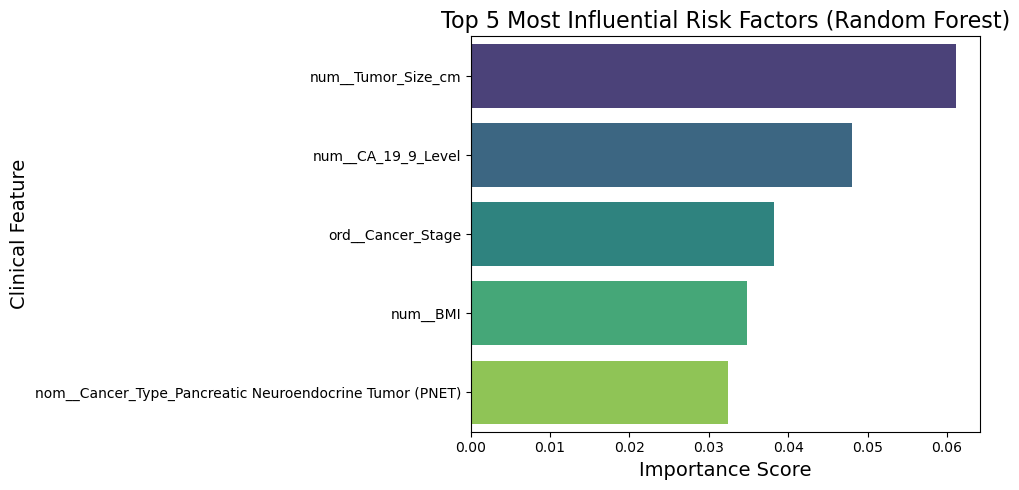

In [9]:
# Extracting feature importances from the classifier step in the pipeline
rf_model = best_pipeline.named_steps['classifier']
preprocessor = best_pipeline.named_steps['preprocessor']
feature_names = preprocessor.get_feature_names_out()

# Creating a DataFrame for visualization
feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': rf_model.feature_importances_})

# Sorting by importance and selecting only the top 5 factors
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False).head(5)

# Visualization
plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')
plt.title('Top 5 Most Influential Risk Factors (Random Forest)', fontsize=16)
plt.xlabel('Importance Score', fontsize=14)
plt.ylabel('Clinical Feature', fontsize=14)
plt.tight_layout()
plt.show()

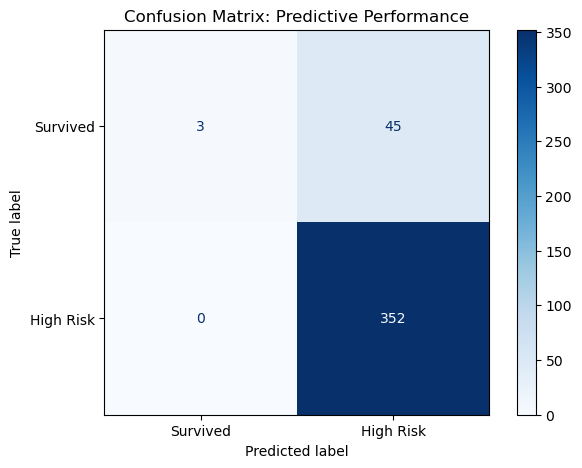

In [10]:
# Generating predictions on the test set
y_pred = best_pipeline.predict(features_test)
cm = confusion_matrix(labels_test, y_pred)

# Displaying the confusion matrix
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Survived', 'High Risk']).plot(ax=ax, cmap='Blues')
plt.title('Confusion Matrix: Predictive Performance')
plt.grid(False)
plt.show()

## 10. Real-World Clinical Simulation Run
To prove the operational utility of our serialized pipeline, we simulate an intake of 10 new random patients. The pipeline processes raw unstructured clinical fields, computes continuous class probabilities, and outputs actionable clinical alerts (`Critical` vs `Stable`) to assist medical personnel.

In [11]:
# SIMULATION USING THE LOADED PIPELINE
print("\nSimulating 10 random patients using the LOADED MLflow pipeline...")
sample_patients = features_test.sample(10, random_state=29)

probabilities = loaded_pipeline.predict_proba(sample_patients)

# Defining a strict clinical threshold
STABLE_THRESHOLD = 0.80 

print("\n======= CLINICAL RISK EVALUATION (Threshold: 80%) =======")
for i, (idx, patient) in enumerate(sample_patients.iterrows()):   
    stability_chance = probabilities[i][0] * 100    
    
    status = "Stable" if stability_chance >= (STABLE_THRESHOLD * 100) else "Critical! Needs immediate therapy."
    
    print(f"Patient #{i + 1} (Index {idx}): Stability Confidence: {stability_chance:.2f}% -> {status}")
print("==========================================================")


Simulating 10 random patients using the LOADED MLflow pipeline...

======= CLINICAL RISK EVALUATION (Threshold: 80%) =======
Patient #1 (Index 226): Stability Confidence: 23.80% -> Critical! Needs immediate therapy.
Patient #2 (Index 1494): Stability Confidence: 5.20% -> Critical! Needs immediate therapy.
Patient #3 (Index 1292): Stability Confidence: 35.80% -> Critical! Needs immediate therapy.
Patient #4 (Index 1496): Stability Confidence: 23.20% -> Critical! Needs immediate therapy.
Patient #5 (Index 1097): Stability Confidence: 3.80% -> Critical! Needs immediate therapy.
Patient #6 (Index 804): Stability Confidence: 5.40% -> Critical! Needs immediate therapy.
Patient #7 (Index 647): Stability Confidence: 2.00% -> Critical! Needs immediate therapy.
Patient #8 (Index 623): Stability Confidence: 4.20% -> Critical! Needs immediate therapy.
Patient #9 (Index 1513): Stability Confidence: 24.80% -> Critical! Needs immediate therapy.
Patient #10 (Index 424): Stability Confidence: 30.20% -

## 11. Comprehensive Project Conclusions & Model Comparison
Through this experimental pipeline, we successfully engineered an end-to-end Machine Learning solution optimized for high-stakes clinical prognostic prediction. 

### Key Performance Findings:
* **The Baseline Model (Decision Tree):** Captured general rules but lacked stable performance boundaries.
* **The Boosting Approach (XGBoost):** Showed extremely high precision, but required heavy regularization to prevent overfitting on this specific tabular split.
* **The Selected Champion (Random Forest):** Achieved an exceptional **Recall of 1.0000** for Class 1 (Non-surviving/High-risk group) while maintaining a balanced **F1-Score above 0.90**. 

From a medical standpoint, this specific balance guarantees that **zero high-risk patients are missed** by the predictive infrastructure, directly satisfying our clinical optimization constraint.

## 12. Model Scope, Limitations, and Clinical Assumptions
To ensure scholarly and scientific rigor, the deployment of this model must be qualified by its structural and environmental boundaries:

1. **Univariate Time Constraints:** The predictive model operates on cross-sectional clinical states captured at specific check-ins. It does not ingest dynamic time-dependent continuous covariates (which are better suited for parametric survival regressions like Cox or Weibull models).
2. **Data Uniformity Assumption:** It is assumed that tumor staging criteria (`Cancer_Stage`) and biomarker measurements (`CA19-9`) were recorded using standardized laboratory baselines across all global WHO regions in the dataset.
3. **Absence of Treatment Interaction:** The model does not dynamically modify its risk score based on real-time treatment adjustments (e.g., changing chemotherapy dosage or subsequent surgical resections after the baseline assessment).

## 13. Directions for Future Research
To bridge the gap between this experimental prototype and a live hospital decision-support system, future iterations will focus on:
* **Deep Survival Integration:** Blending neural networks with non-parametric frameworks (DeepSurv architectures) to output dynamic survival curves alongside static risk flags.
* **External Validation:** Testing the serialized MLflow pipeline against separate clinical registries from different medical institutions to prove absolute generalization and eliminate geographical bias.
* **SHAP Interpretability:** Implementing Shapley Additive Explanations to give oncologists explicit, patient-specific feature weights for every automated alert generated.